# 📊 Klasifikasi Emosi Tweet Indonesia
## Mini Project - Sequence Model

**Dataset:** Indonesian Twitter Emotion Dataset (Saputri et al., 2018)  
**Models:** RNN, LSTM, GRU  
**Embedding:** Word2Vec Bahasa Indonesia (Wikipedia)  
**Reference Paper:** IEEE 8629262 — F1-score baseline = 69.73%

## 1. Import Libraries

In [1]:
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
%matplotlib inline

print(f'PyTorch: {torch.__version__}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else
                       'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')

PyTorch: 2.8.0
Device: mps


## 2. Konfigurasi & Hyperparameter

In [2]:
DATA_DIR = 'data'
MODEL_DIR = os.path.join('models', 'word2vec_id')
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

SEED = 42
EMBEDDING_DIM = 100
MAX_SEQ_LEN = 50
BATCH_SIZE = 64
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.3
LEARNING_RATE = 1e-3
NUM_EPOCHS = 30
PATIENCE = 5

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print('Configuration loaded.')

Configuration loaded.


## 3. Load Dataset & Eksplorasi Data

In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, 'Twitter_Emotion_Dataset.csv'))
print(f'Total samples: {len(df)}')
print(f'Columns: {list(df.columns)}')
print(f'\nSample data:')
df.head()

Total samples: 4401
Columns: ['label', 'tweet']

Sample data:


,label,tweet
0,anger,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu..."
1,anger,"Sesama cewe lho (kayaknya), harusnya bisa lebi..."
2,happy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...
3,anger,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng..."
4,happy,"Sharing pengalaman aja, kemarin jam 18.00 bata..."


In [4]:
label_counts = df['label'].value_counts()
print('Label distribution:')
print(label_counts)
print(f'\nPercentage:')
print((label_counts / len(df) * 100).round(1))

Label distribution:
label
anger      1101
happy      1017
sadness     997
fear        649
love        637
Name: count, dtype: int64

Percentage:
label
anger      25.0
happy      23.1
sadness    22.7
fear       14.7
love       14.5
Name: count, dtype: float64


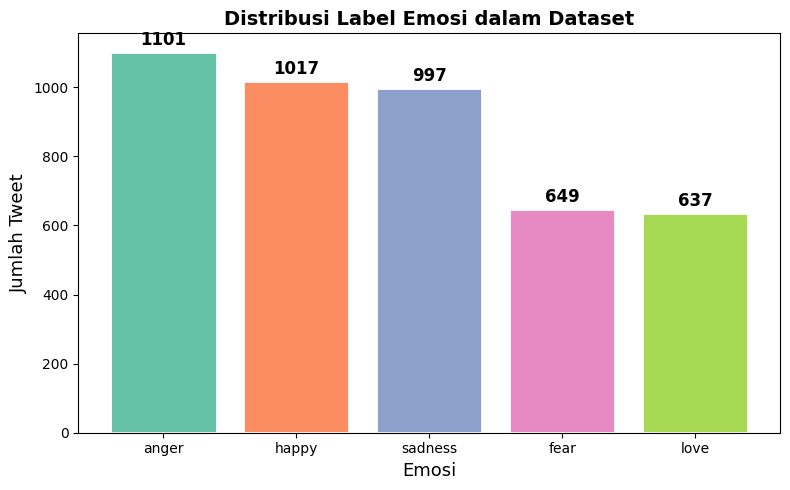

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
palette = sns.color_palette('Set2', len(label_counts))
bars = ax.bar(label_counts.index, label_counts.values, color=palette, edgecolor='white', linewidth=2)
for bar, count in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            str(count), ha='center', fontsize=12, fontweight='bold')
ax.set_title('Distribusi Label Emosi dalam Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Emosi', fontsize=13)
ax.set_ylabel('Jumlah Tweet', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'data_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Text Preprocessing

In [6]:
abbrev_df = pd.read_csv(
    os.path.join(DATA_DIR, 'kamus_singkatan.csv'),
    sep=';', header=None, names=['abbrev', 'full']
)
abbrev_dict = dict(zip(abbrev_df['abbrev'].str.strip(), abbrev_df['full'].str.strip()))
print(f'Abbreviation dictionary: {len(abbrev_dict)} entries')
print('\nContoh:')
list(abbrev_dict.items())[:10]

Abbreviation dictionary: 1243 entries

Contoh:


[('aamiin', 'amin'),
 ('adek', 'adik'),
 ('adlh', 'adalah'),
 ('aer', 'air'),
 ('aiskrim', 'es krim'),
 ('aj', 'saja'),
 ('aja', 'saja'),
 ('ajah', 'saja'),
 ('ajalah', 'saja'),
 ('aje', 'saja')]

In [7]:
def preprocess_text(text, abbrev_dict):
    """Clean and normalize Indonesian tweet text."""
    text = str(text).lower()
    text = re.sub(r'\[username\]', '', text)
    text = re.sub(r'\[url\]', '', text)
    text = re.sub(r'\[sensitive-no\]', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    words = text.split()
    words = [abbrev_dict.get(w, w) for w in words]
    text = ' '.join(words).strip()
    text = re.sub(r'\s+', ' ', text)
    return text

df['clean_tweet'] = df['tweet'].apply(lambda x: preprocess_text(x, abbrev_dict))
df['tokens'] = df['clean_tweet'].apply(lambda x: x.split())

print('Contoh preprocessing:')
for i in range(3):
    print(f'\n--- Sample {i+1} ---')
    print(f'  Original : {df["tweet"].iloc[i][:100]}...')
    print(f'  Cleaned  : {df["clean_tweet"].iloc[i][:100]}...')

Contoh preprocessing:

--- Sample 1 ---
  Original : Soal jln Jatibaru,polisi tdk bs GERTAK gubernur .Emangny polisi tdk ikut pmbhasan? Jgn berpolitik. P...
  Cleaned  : soal jalan jatibaru polisi tidak bisa gertak gubernur emangny polisi tidak ikut pmbhasan jangan berp...

--- Sample 2 ---
  Original : Sesama cewe lho (kayaknya), harusnya bisa lebih rasain lah yang harus sibuk jaga diri, rasain sakitn...
  Cleaned  : sesama cewek lho kayaknya harusnya bisa lebih rasain lah yang harus sibuk jaga diri rasain sakitnya ...

--- Sample 3 ---
  Original : Kepingin gudeg mbarek Bu hj. Amad Foto dari google, sengaja, biar teman-teman jg membayangkannya. Be...
  Cleaned  : kepingin gudeg mbarek bu hj amad foto dari google sengaja biar teman teman juga membayangkannya berb...


Token length statistics:
  Mean  : 28.2
  Median: 27
  Max   : 82
  95th  : 44


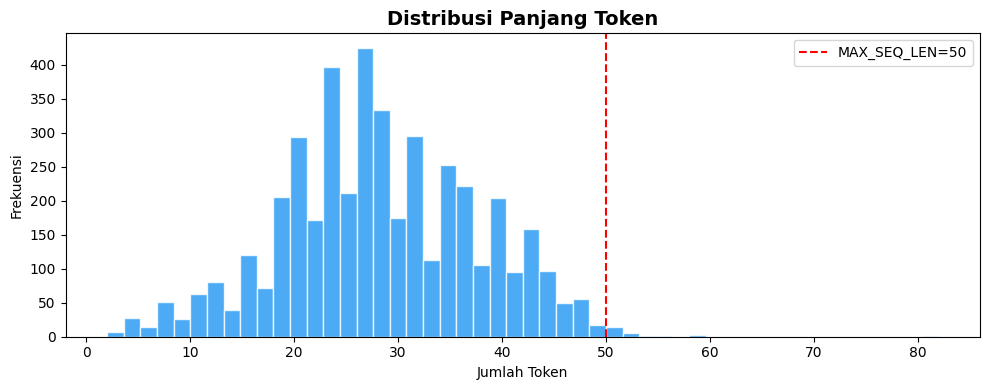

In [8]:
lengths = df['tokens'].apply(len)
print(f'Token length statistics:')
print(f'  Mean  : {lengths.mean():.1f}')
print(f'  Median: {lengths.median():.0f}')
print(f'  Max   : {lengths.max()}')
print(f'  95th  : {lengths.quantile(0.95):.0f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths, bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
ax.axvline(x=MAX_SEQ_LEN, color='red', linestyle='--', label=f'MAX_SEQ_LEN={MAX_SEQ_LEN}')
ax.set_title('Distribusi Panjang Token', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Token')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Label Encoding

In [9]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
label_names = list(le.classes_)
num_classes = len(label_names)
print(f'Classes: {label_names}')
print(f'Num classes: {num_classes}')
print(f'\nMapping:')
for i, name in enumerate(label_names):
    print(f'  {i} -> {name}')

Classes: ['anger', 'fear', 'happy', 'love', 'sadness']
Num classes: 5

Mapping:
  0 -> anger
  1 -> fear
  2 -> happy
  3 -> love
  4 -> sadness


## 6. Load Word2Vec Embedding

In [10]:
w2v_path = os.path.join(MODEL_DIR, f'idwiki_word2vec_{EMBEDDING_DIM}.model')
w2v_model = Word2Vec.load(w2v_path)
w2v_vocab = set(w2v_model.wv.key_to_index.keys())
print(f'Word2Vec vocabulary size: {len(w2v_vocab):,}')
print(f'Embedding dimension: {w2v_model.wv.vector_size}')

print(f'\nContoh kata mirip dengan "senang":')
try:
    for word, sim in w2v_model.wv.most_similar('senang', topn=5):
        print(f'  {word}: {sim:.4f}')
except KeyError:
    print('  (kata tidak ditemukan di vocabulary)')

Word2Vec vocabulary size: 331,792
Embedding dimension: 100

Contoh kata mirip dengan "senang":
  suka: 0.8011
  bersemangat: 0.7315
  kesal: 0.7050
  menyenangkan: 0.6991
  takjub: 0.6962


## 7. Build Vocabulary & Embedding Matrix

In [11]:
word_freq = {}
for tokens in df['tokens']:
    for token in tokens:
        word_freq[token] = word_freq.get(token, 0) + 1

word2idx = {'<PAD>': 0, '<UNK>': 1}
idx = 2
for word, freq in sorted(word_freq.items(), key=lambda x: -x[1]):
    word2idx[word] = idx
    idx += 1

vocab_size = len(word2idx)
print(f'Dataset vocabulary size: {vocab_size:,}')

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
found = 0
for word, i in word2idx.items():
    if word in w2v_vocab:
        embedding_matrix[i] = w2v_model.wv[word]
        found += 1
    elif i > 1:
        embedding_matrix[i] = np.random.normal(0, 0.1, EMBEDDING_DIM)

print(f'Words found in Word2Vec: {found}/{vocab_size} ({found/vocab_size*100:.1f}%)')
del w2v_model
print('Embedding matrix ready.')

Dataset vocabulary size: 17,900
Words found in Word2Vec: 12795/17900 (71.5%)
Embedding matrix ready.


## 8. Dataset & DataLoader

In [12]:
def encode_tokens(tokens, word2idx, max_len):
    encoded = [word2idx.get(t, word2idx['<UNK>']) for t in tokens[:max_len]]
    if len(encoded) < max_len:
        encoded += [word2idx['<PAD>']] * (max_len - len(encoded))
    return encoded

df['encoded'] = df['tokens'].apply(lambda x: encode_tokens(x, word2idx, MAX_SEQ_LEN))

class EmotionDataset(Dataset):
    def __init__(self, encodeds, labels):
        self.encodeds = torch.LongTensor(encodeds)
        self.labels = torch.LongTensor(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.encodeds[idx], self.labels[idx]

X = np.array(df['encoded'].tolist())
y = np.array(df['label_encoded'].tolist())

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

train_dataset = EmotionDataset(X_train, y_train)
val_dataset = EmotionDataset(X_val, y_val)
test_dataset = EmotionDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print('DataLoaders ready.')

Train: 3520, Val: 440, Test: 441
DataLoaders ready.


## 9. Definisi Model: RNN, LSTM, GRU

Tiga varian model Recurrent Neural Network:
1. **Simple RNN** — Vanilla recurrent network
2. **LSTM** — Long Short-Term Memory, mengatasi vanishing gradient
3. **GRU** — Gated Recurrent Unit, lebih sederhana dari LSTM

Semua model menggunakan:
- Pre-trained Word2Vec embedding layer
- 2-layer RNN dengan dropout
- Dense output layer (5 classes)

In [13]:
class EmotionClassifier(nn.Module):
    def __init__(self, rnn_type, vocab_size, embedding_dim, hidden_dim,
                 num_layers, num_classes, embedding_matrix, dropout=0.3):
        super(EmotionClassifier, self).__init__()
        self.rnn_type = rnn_type
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.FloatTensor(embedding_matrix), requires_grad=True
        )

        rnn_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[rnn_type]
        self.rnn = rnn_cls(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        if self.rnn_type == 'LSTM':
            output, (hidden, _) = self.rnn(embedded)
        else:
            output, hidden = self.rnn(embedded)
        hidden_last = self.dropout(hidden[-1])
        return self.fc(hidden_last)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Model class defined.')

Model class defined.


## 10. Training & Evaluation Functions

In [14]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return total_loss / len(loader.dataset), np.array(all_preds), np.array(all_labels)

def train_model(model, model_name, train_loader, val_loader, criterion,
                optimizer, scheduler, device, num_epochs, patience):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_f1 = 0
    best_model_state = None
    patience_counter = 0

    print(f'\n{"="*60}')
    print(f'  Training {model_name} | Params: {count_parameters(model):,}')
    print(f'{"="*60}')

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='macro')
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:02d}/{num_epochs} | '
                  f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
                  f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

    model.load_state_dict(best_model_state)
    return model, history

print('Training functions defined.')

Training functions defined.


## 11. Training Semua Model

Melatih 3 model: **RNN**, **LSTM**, **GRU**

In [15]:
model_types = ['RNN', 'LSTM', 'GRU']
results = {}
histories = {}
all_test_preds = {}
embedding_tensor = embedding_matrix.copy()

for rnn_type in model_types:
    set_seed(SEED)
    model = EmotionClassifier(
        rnn_type=rnn_type, vocab_size=vocab_size,
        embedding_dim=EMBEDDING_DIM, hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS, num_classes=num_classes,
        embedding_matrix=embedding_tensor, dropout=DROPOUT
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    model, history = train_model(
        model, rnn_type, train_loader, val_loader,
        criterion, optimizer, scheduler, DEVICE, NUM_EPOCHS, PATIENCE
    )

    test_loss, test_preds, test_labels = evaluate(model, test_loader, criterion, DEVICE)
    test_acc = accuracy_score(test_labels, test_preds)
    test_f1 = f1_score(test_labels, test_preds, average='macro')
    test_prec = precision_score(test_labels, test_preds, average='macro')
    test_rec = recall_score(test_labels, test_preds, average='macro')

    results[rnn_type] = {
        'accuracy': test_acc, 'precision': test_prec,
        'recall': test_rec, 'f1_score': test_f1,
        'params': count_parameters(model)
    }
    histories[rnn_type] = history
    all_test_preds[rnn_type] = (test_preds, test_labels)

    print(f'\n  {rnn_type} Test Results:')
    print(f'    Accuracy:  {test_acc:.4f}')
    print(f'    Precision: {test_prec:.4f}')
    print(f'    Recall:    {test_rec:.4f}')
    print(f'    F1-Score:  {test_f1:.4f}')

print('\n✅ All models trained!')


  Training RNN | Params: 1,853,109


  Epoch 01/30 | Train Loss: 1.5941 Acc: 0.2398 | Val Loss: 1.5857 Acc: 0.2432 F1: 0.0787


  Epoch 05/30 | Train Loss: 1.5679 Acc: 0.2594 | Val Loss: 1.5988 Acc: 0.2136 F1: 0.1144


  Epoch 10/30 | Train Loss: 1.5036 Acc: 0.3119 | Val Loss: 1.6467 Acc: 0.2205 F1: 0.1375


  Epoch 15/30 | Train Loss: 1.4153 Acc: 0.3739 | Val Loss: 1.7266 Acc: 0.2250 F1: 0.1864


...

  Epoch 01/30 | Train Loss: 1.5877 Acc: 0.2435 | Val Loss: 1.5807 Acc: 0.2500 F1: 0.0801


  Epoch 05/30 | Train Loss: 1.2759 Acc: 0.4568 | Val Loss: 1.2093 Acc: 0.4659 F1: 0.4031


  Epoch 10/30 | Train Loss: 0.6958 Acc: 0.7480 | Val Loss: 1.1174 Acc: 0.6205 F1: 0.6300


  Epoch 15/30 | Train Loss: 0.3541 Acc: 0.8898 | Val Loss: 1.2700 Acc: 0.6045 F1: 0.6303


  Early stopping at epoch 17

  GRU Test Results:
    Accuracy:  0.6508
    Precision: 0.6953
    Recall:    0.6556
    F1-Score:  0.6699

✅ All models trained!


## 12. Classification Report per Model

In [16]:
for name, (preds, labels) in all_test_preds.items():
    print(f'\n{"="*50}')
    print(f'  Classification Report: {name}')
    print(f'{"="*50}')
    print(classification_report(labels, preds, target_names=label_names, digits=4))


  Classification Report: RNN
              precision    recall  f1-score   support

       anger     0.2209    0.3273    0.2637       110
        fear     0.2353    0.1231    0.1616        65
       happy     0.2432    0.2647    0.2535       102
        love     0.0645    0.0312    0.0421        64
     sadness     0.2647    0.2700    0.2673       100

    accuracy                         0.2268       441
   macro avg     0.2057    0.2033    0.1977       441
weighted avg     0.2154    0.2268    0.2150       441


  Classification Report: LSTM
              precision    recall  f1-score   support

       anger     0.7059    0.6545    0.6792       110
        fear     0.6949    0.6308    0.6613        65
       happy     0.6757    0.4902    0.5682       102
        love     0.8421    0.7500    0.7934        64
     sadness     0.3893    0.5800    0.4659       100

    accuracy                         0.6100       441
   macro avg     0.6616    0.6211    0.6336       441
weighted avg    

## 13. Perbandingan dengan Paper (IEEE 8629262)

Paper reference: Mei Silviana Saputri, Rahmad Mahendra, and Mirna Adriani,  
"Emotion Classification on Indonesian Twitter Dataset",  
Proc. IALP 2018. **F1-score = 69.73%**

In [17]:
paper_f1 = 69.73

print(f'{"="*70}')
print(f'  PERBANDINGAN: RNN Variants vs Paper (Saputri et al., 2018)')
print(f'{"="*70}')
print()
print(f'  {"Model":<12} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"Params":>12}')
print(f'  {"-"*12} {"-"*10} {"-"*10} {"-"*10} {"-"*10} {"-"*12}')

for model_name, r in results.items():
    print(f'  {model_name:<12} {r["accuracy"]*100:>9.2f}% {r["precision"]*100:>9.2f}% '
          f'{r["recall"]*100:>9.2f}% {r["f1_score"]*100:>9.2f}% {r["params"]:>12,}')

print(f'  {"Paper":<12} {"N/A":>10} {"N/A":>10} {"N/A":>10} {paper_f1:>9.2f}% {"N/A":>12}')
print()

best_model_name = max(results, key=lambda k: results[k]['f1_score'])
best_f1 = results[best_model_name]['f1_score'] * 100
diff = best_f1 - paper_f1
print(f'  🏆 Best Model: {best_model_name} (F1: {best_f1:.2f}%)')
if diff > 0:
    print(f'  >> Mengungguli paper sebesar {diff:.2f}%')
else:
    print(f'  >> Di bawah paper sebesar {abs(diff):.2f}%')

  PERBANDINGAN: RNN Variants vs Paper (Saputri et al., 2018)

  Model          Accuracy  Precision     Recall   F1-Score       Params
  ------------ ---------- ---------- ---------- ---------- ------------
  RNN              22.68%     20.57%     20.33%     19.77%    1,853,109
  LSTM             61.00%     66.16%     62.11%     63.36%    2,040,501
  GRU              65.08%     69.53%     65.56%     66.99%    1,978,037
  Paper               N/A        N/A        N/A     69.73%          N/A

  🏆 Best Model: GRU (F1: 66.99%)
  >> Di bawah paper sebesar 2.74%


In [18]:
comp_data = []
for model_name, r in results.items():
    comp_data.append({
        'Model': model_name,
        'Accuracy (%)': round(r['accuracy'] * 100, 2),
        'Precision (%)': round(r['precision'] * 100, 2),
        'Recall (%)': round(r['recall'] * 100, 2),
        'F1-Score (%)': round(r['f1_score'] * 100, 2),
        'Parameters': f"{r['params']:,}"
    })
comp_data.append({
    'Model': 'Paper (Saputri 2018)',
    'Accuracy (%)': '-', 'Precision (%)': '-',
    'Recall (%)': '-', 'F1-Score (%)': paper_f1,
    'Parameters': '-'
})
comp_df = pd.DataFrame(comp_data)
comp_df

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Parameters
0,RNN,22.68,20.57,20.33,19.77,"1,853,109"
1,LSTM,61.0,66.16,62.11,63.36,"2,040,501"
2,GRU,65.08,69.53,65.56,66.99,"1,978,037"
3,Paper (Saputri 2018),-,-,-,69.73,-


## 14. Visualisasi Hasil

### 14.1 Training & Validation Curves

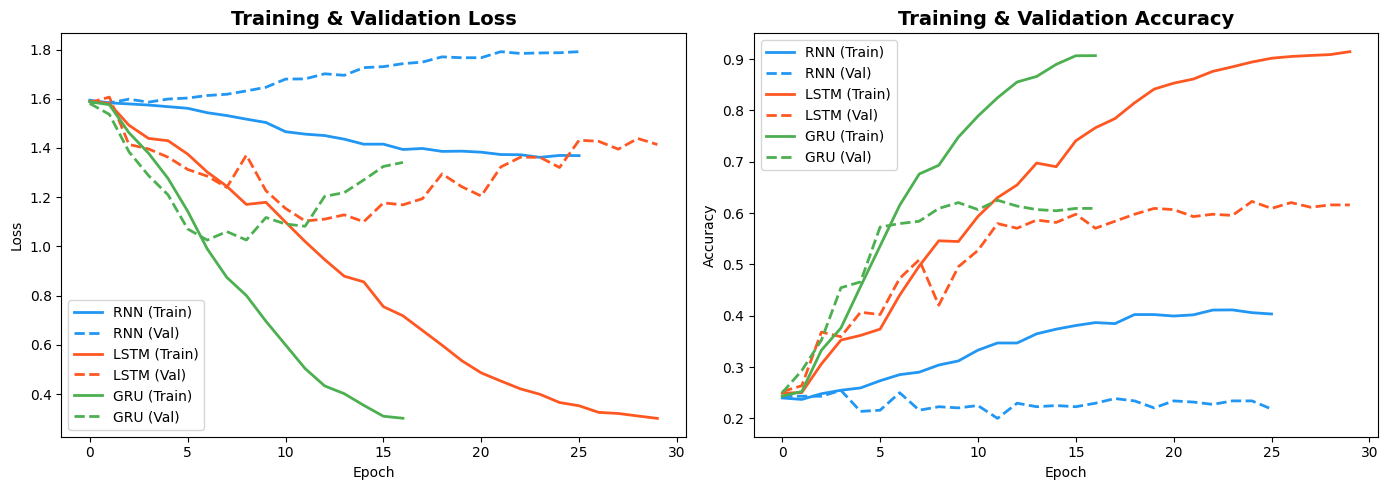

In [19]:
colors = ['#2196F3', '#FF5722', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, hist) in enumerate(histories.items()):
    axes[0].plot(hist['train_loss'], label=f'{name} (Train)', color=colors[i], linewidth=2)
    axes[0].plot(hist['val_loss'], label=f'{name} (Val)', color=colors[i], linewidth=2, linestyle='--')
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

for i, (name, hist) in enumerate(histories.items()):
    axes[1].plot(hist['train_acc'], label=f'{name} (Train)', color=colors[i], linewidth=2)
    axes[1].plot(hist['val_acc'], label=f'{name} (Val)', color=colors[i], linewidth=2, linestyle='--')
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

### 14.2 Perbandingan F1-Score

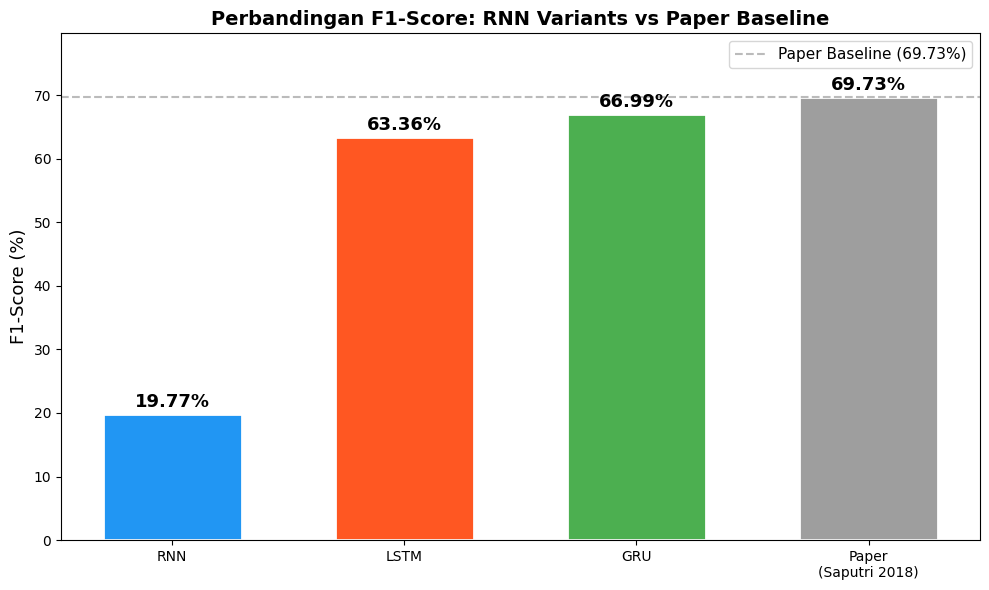

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

model_names_plot = list(results.keys()) + ['Paper\n(Saputri 2018)']
f1_scores = [results[m]['f1_score'] * 100 for m in results] + [paper_f1]
bar_colors = colors + ['#9E9E9E']

bars = ax.bar(model_names_plot, f1_scores, color=bar_colors, edgecolor='white', linewidth=2, width=0.6)

for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{score:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('F1-Score (%)', fontsize=13)
ax.set_title('Perbandingan F1-Score: RNN Variants vs Paper Baseline',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(f1_scores) + 10)
ax.axhline(y=paper_f1, color='#9E9E9E', linestyle='--', alpha=0.7, label=f'Paper Baseline ({paper_f1}%)')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### 14.3 Confusion Matrix

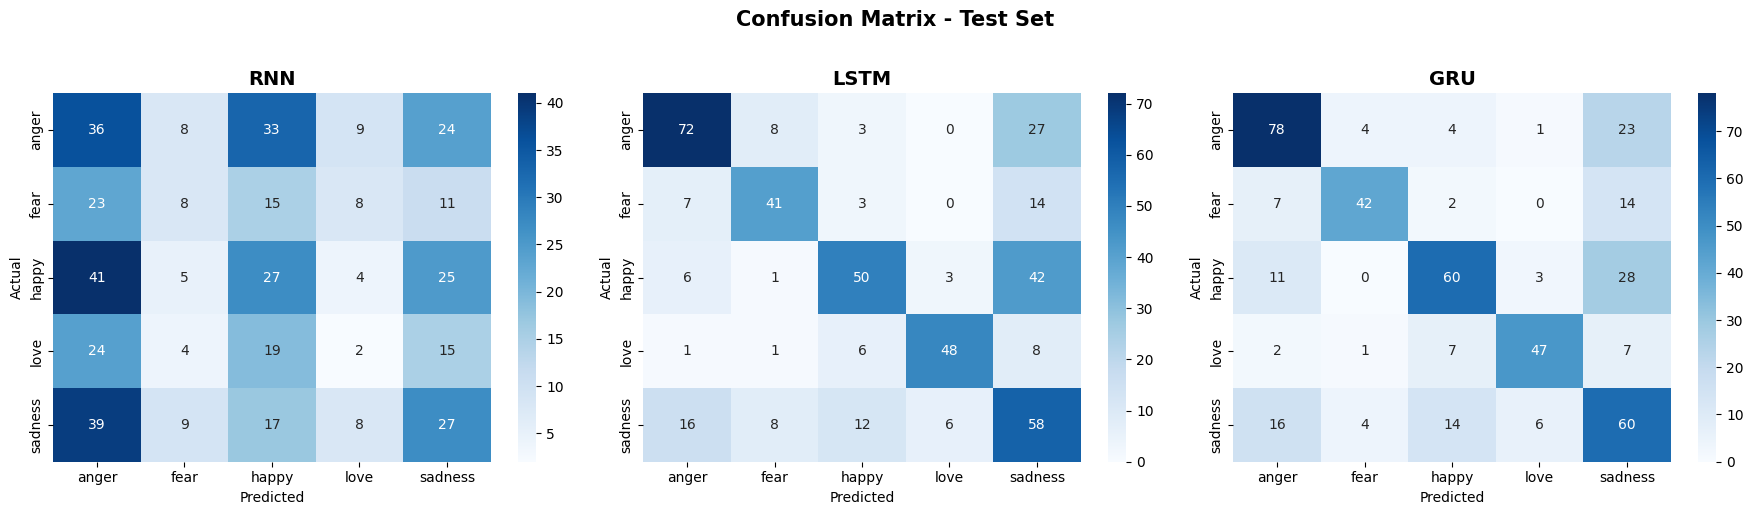

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, (preds, labels)) in enumerate(all_test_preds.items()):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=label_names, yticklabels=label_names)
    axes[i].set_title(f'{name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrix - Test Set', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

### 14.4 Per-Class F1-Score

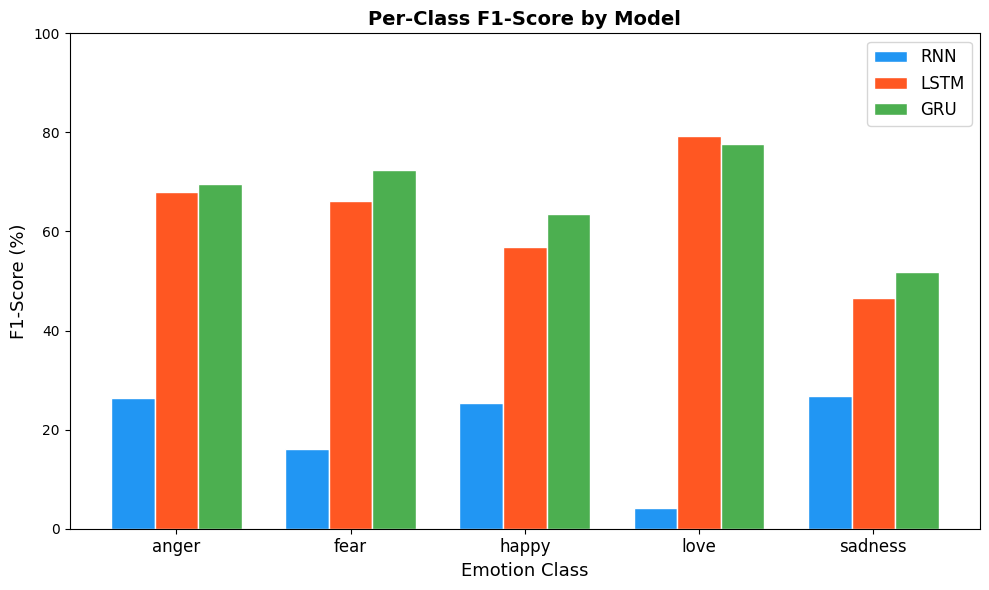

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(label_names))
width = 0.25

for i, (name, (preds, labels)) in enumerate(all_test_preds.items()):
    report = classification_report(labels, preds, target_names=label_names, output_dict=True)
    class_f1 = [report[c]['f1-score'] * 100 for c in label_names]
    ax.bar(x + i * width, class_f1, width, label=name, color=colors[i], edgecolor='white')

ax.set_xlabel('Emotion Class', fontsize=13)
ax.set_ylabel('F1-Score (%)', fontsize=13)
ax.set_title('Per-Class F1-Score by Model', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(label_names, fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'per_class_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. Kesimpulan

### Ringkasan Hasil
- Tiga model RNN variants (RNN, LSTM, GRU) telah dilatih untuk klasifikasi emosi tweet Indonesia
- Dataset terdiri dari 4.401 tweet dengan 5 kelas emosi: anger, fear, happy, love, sadness
- Word2Vec Bahasa Indonesia (100 dimensi) digunakan sebagai pre-trained word embedding
- Hasil dibandingkan dengan paper baseline (Saputri et al., 2018) yang mencapai F1-score 69.73%

### Reference
Mei Silviana Saputri, Rahmad Mahendra, and Mirna Adriani,  
"Emotion Classification on Indonesian Twitter Dataset",  
in Proceeding of International Conference on Asian Language Processing 2018. (IEEE 8629262)